# EDA-Streaming

### All Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns

### Load Data

In [2]:
df = pd.read_csv("spreadsheets/streaming.csv")
df.groupby("streaming").count()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22998 entries, 0 to 22997
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          22998 non-null  object
 1   title         22998 non-null  object
 2   country       11499 non-null  object
 3   date_added    13356 non-null  object
 4   release_year  22998 non-null  int64 
 5   rating        22134 non-null  object
 6   duration      22516 non-null  object
 7   listed_in     22998 non-null  object
 8   description   22994 non-null  object
 9   streaming     22998 non-null  object
dtypes: int64(1), object(9)
memory usage: 1.8+ MB


### EDA

#### Missing Values - Search

In [3]:
streaming_na = df.isna().groupby(df["streaming"]).sum()

<Figure size 1400x700 with 0 Axes>

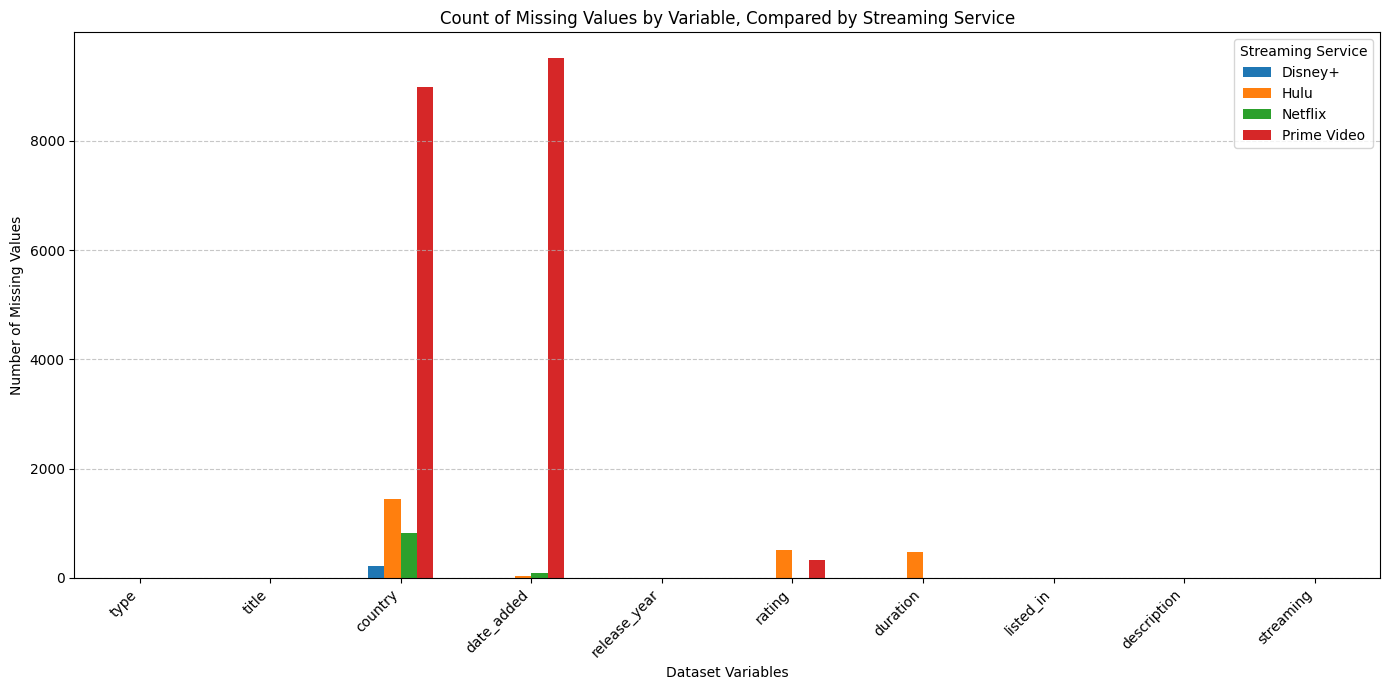

In [4]:
plt.figure(figsize=(14, 7))
streaming_na.T.plot(
    kind='bar', 
    figsize=(14, 7), 
    title='Count of Missing Values by Variable, Compared by Streaming Service'
)

plt.ylabel('Number of Missing Values')
plt.xlabel('Dataset Variables')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Streaming Service')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Anomaly - Search

In [5]:
df["country"].unique() # Clean

array(['United States', 'South Africa', nan, 'India',
       'United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia',
       'United Kingdom', 'Germany, Czech Republic', 'Mexico', 'Turkey',
       'Australia', 'United States, India, France', 'Finland',
       'China, Canada, United States',
       'South Africa, United States, Japan', 'Nigeria', 'Japan',
       'Spain, United States', 'France', 'Belgium',
       'United Kingdom, United States', 'United States, United Kingdom',
       'France, United States', 'South Korea', 'Spain',
       'United States, Singapore', 'United Kingdom, Australia, France',
       'United Kingdom, Australia, France, United States',
       'United States, Canada', 'Germany, United States',
       'South Africa, United States', 'United States, Mexico',
       'United States, Italy, France, Japan',
       'United States, Italy, Romania, United Kingdom',
       'Australia, United States', 'Argentina, Venezuela',
       'United States, United Kin

In [6]:
df[(df["release_year"]<1928) | (df["release_year"]>2025)]["release_year"]

4250     1925
8890     1920
9292     1925
9492     1925
9941     1924
9950     1922
9979     1926
10091    1920
10232    1922
10281    1920
10491    1923
10583    1925
11436    1925
13166    1926
13891    1927
15434    1925
16405    1925
16425    1925
17397    1925
22057    1923
Name: release_year, dtype: int64

In [7]:
df["rating"].unique() # Clean

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', '74 min', '84 min', '66 min', 'NR', nan,
       'TV-Y7-FV', 'UR', '13+', 'ALL', '18+', '16+', '7+', 'TV-NR',
       'UNRATED', '16', 'AGES_16_', 'AGES_18_', 'ALL_AGES', 'NOT_RATE',
       'NOT RATED', '2 Seasons', '93 min', '4 Seasons', '136 min',
       '91 min', '85 min', '98 min', '89 min', '94 min', '86 min',
       '3 Seasons', '121 min', '88 min', '101 min', '1 Season', '83 min',
       '100 min', '95 min', '92 min', '96 min', '109 min', '99 min',
       '75 min', '87 min', '67 min', '104 min', '107 min', '103 min',
       '105 min', '119 min', '114 min', '82 min', '90 min', '130 min',
       '110 min', '80 min', '6 Seasons', '97 min', '111 min', '81 min',
       '49 min', '45 min', '41 min', '73 min', '40 min', '36 min',
       '39 min', '34 min', '47 min', '65 min', '37 min', '78 min',
       '102 min', '129 min', '115 min', '112 min', '61 min', '106 min',
       '76 min', '77 mi

In [8]:
df["duration"].unique() # Clean and discretise

array(['90 min', '2 Seasons', '1 Season', '91 min', '125 min',
       '9 Seasons', '104 min', '127 min', '4 Seasons', '67 min', '94 min',
       '5 Seasons', '161 min', '61 min', '166 min', '147 min', '103 min',
       '97 min', '106 min', '111 min', '3 Seasons', '110 min', '105 min',
       '96 min', '124 min', '116 min', '98 min', '23 min', '115 min',
       '122 min', '99 min', '88 min', '100 min', '6 Seasons', '102 min',
       '93 min', '95 min', '85 min', '83 min', '113 min', '13 min',
       '182 min', '48 min', '145 min', '87 min', '92 min', '80 min',
       '117 min', '128 min', '119 min', '143 min', '114 min', '118 min',
       '108 min', '63 min', '121 min', '142 min', '154 min', '120 min',
       '82 min', '109 min', '101 min', '86 min', '229 min', '76 min',
       '89 min', '156 min', '112 min', '107 min', '129 min', '135 min',
       '136 min', '165 min', '150 min', '133 min', '70 min', '84 min',
       '140 min', '78 min', '7 Seasons', '64 min', '59 min', '139 min',
    

In [9]:
df["listed_in"].unique() # Clean and discretise

array(['Documentaries', 'International TV Shows, TV Dramas, TV Mysteries',
       'Crime TV Shows, International TV Shows, TV Action & Adventure',
       ..., 'Comedy, Family, History', 'Comedy, Horror, Mystery',
       'Classics, Science Fiction, Thriller'], shape=(1687,), dtype=object)

In [10]:
df["streaming"].unique()

array(['Netflix', 'Prime Video', 'Disney+', 'Hulu'], dtype=object)

#### Clean

##### Duration TV Shows - Seasons

In [11]:
print("TV Show (Before):")
movie_durations_before = df[df["type"] == "TV Show"]["duration"]
print(f"Unique values (array): {movie_durations_before.unique()}")

count_before = movie_durations_before.nunique()
print(f"Number of unique values (Before): {count_before}")

df.loc[df["type"] == "TV Show", "duration"] = (
    df[df["type"] == "TV Show"]["duration"]
    .astype(str)
    .str.extract(r'(\d+)', expand=False)
    .astype(float)
    .astype('Int64')
)


print("\nAfter conversion:")
movie_durations_after = df[df["type"] == "TV Show"]["duration"]
print(f"Unique values (array): {movie_durations_after.unique()}")

count_after = movie_durations_after.nunique()
print(f"Number of unique values (After): {count_after}")

print("\nVerification:")
print(f"Is the count the same? {count_before == count_after}")

TV Show (Before):
Unique values (array): ['2 Seasons' '1 Season' '9 Seasons' '4 Seasons' '5 Seasons' '3 Seasons'
 '6 Seasons' '7 Seasons' '10 Seasons' '8 Seasons' '17 Seasons'
 '13 Seasons' '15 Seasons' '12 Seasons' '11 Seasons' '29 Seasons'
 '19 Seasons' '21 Seasons' '14 Seasons' '32 Seasons' '16 Seasons'
 '23 Seasons' '20 Seasons' '30 Seasons' '22 Seasons' '25 Seasons'
 '34 Seasons' '26 Seasons']
Number of unique values (Before): 28

After conversion:
Unique values (array): [2 1 9 4 5 3 6 7 10 8 17 13 15 12 11 29 19 21 14 32 16 23 20 30 22 25 34
 26]
Number of unique values (After): 28

Verification:
Is the count the same? True


##### Duration Movies - Minutes

In [12]:
print("Movies (Before):")
movie_durations_before = df[df["type"] == "Movie"]["duration"]
print(f"Unique values (array): {movie_durations_before.unique()}")

count_before = movie_durations_before.nunique()
print(f"Number of unique values (Before): {count_before}")

df.loc[df["type"] == "Movie", "duration"] = (
    df[df["type"] == "Movie"]["duration"]
    .astype(str)
    .str.extract(r'(\d+)', expand=False)
    .astype(float)
    .astype('Int64')
)


print("\nAfter conversion:")
movie_durations_after = df[df["type"] == "Movie"]["duration"]
print(f"Unique values (array): {movie_durations_after.unique()}")

count_after = movie_durations_after.nunique()
print(f"Number of unique values (After): {count_after}")

print("\nVerification:")
print(f"Is the count the same? {count_before == count_after}")

Movies (Before):
Unique values (array): ['90 min' '91 min' '125 min' '104 min' '127 min' '67 min' '94 min'
 '161 min' '61 min' '166 min' '147 min' '103 min' '97 min' '106 min'
 '111 min' '110 min' '105 min' '96 min' '124 min' '116 min' '98 min'
 '23 min' '115 min' '122 min' '99 min' '88 min' '100 min' '102 min'
 '93 min' '95 min' '85 min' '83 min' '113 min' '13 min' '182 min' '48 min'
 '145 min' '87 min' '92 min' '80 min' '117 min' '128 min' '119 min'
 '143 min' '114 min' '118 min' '108 min' '63 min' '121 min' '142 min'
 '154 min' '120 min' '82 min' '109 min' '101 min' '86 min' '229 min'
 '76 min' '89 min' '156 min' '112 min' '107 min' '129 min' '135 min'
 '136 min' '165 min' '150 min' '133 min' '70 min' '84 min' '140 min'
 '78 min' '64 min' '59 min' '139 min' '69 min' '148 min' '189 min'
 '141 min' '130 min' '138 min' '81 min' '132 min' '123 min' '65 min'
 '68 min' '66 min' '62 min' '74 min' '131 min' '39 min' '46 min' '38 min'
 '126 min' '155 min' '159 min' '137 min' '12 min' '273 mi

##### Rating

In [13]:
print("Rating (Before):")
rating_before = df["rating"]
print(f"Unique values (array): {rating_before.unique()}")

count_before = rating_before.nunique()
print(f"Number of unique values (Before): {count_before}")

rating_mapping = {
    'G': 'G',
    'PG': 'PG',
    'PG-13': 'PG-13',
    'R': 'R',
    'NC-17': 'NC-17',

    'TV-Y': 'TV-Y',
    'TV-Y7': 'TV-Y7',
    'TV-Y7-FV': 'TV-Y7',
    'TV-G': 'TV-G',
    'TV-PG': 'TV-PG',
    'TV-14': 'TV-14',
    'TV-MA': 'TV-MA',
    'TV-NR': 'UNRATED',

    'NR': 'UNRATED',
    'UR': 'UNRATED',
    'UNRATED': 'UNRATED',
    'NOT RATED': 'UNRATED',
    'NOT_RATE': 'UNRATED',
    
    '13+': 'TV-14',
    '16+': 'TV-MA',
    '18+': 'TV-MA',
    '7+': 'TV-Y7',
    '16': 'TV-MA',
    'AGES_16_': 'TV-MA',
    'AGES_18_': 'TV-MA',
    'ALL_AGES': 'G',
    'ALL': 'G'
}

df["rating_clean"] = df["rating"].apply(
    lambda x: (
        'UNRATED' 
        if pd.isna(x) 
        or any(term in str(x).lower() for term in ['min', 'season'])
        else rating_mapping.get(str(x).strip(), 'UNRATED')
    )
)

print("\nAfter conversion:")
rating_after = df["rating_clean"]
print(f"Unique values (array): {rating_after.unique()}")

count_after = rating_after.nunique()
print(f"Number of unique values (After): {count_after}")

print("\nVerification:")
print(f"Is the count the same? {count_before == count_after}")
df["rating"] = df["rating_clean"]


Rating (Before):
Unique values (array): ['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' '74 min' '84 min' '66 min' 'NR' nan 'TV-Y7-FV' 'UR' '13+' 'ALL'
 '18+' '16+' '7+' 'TV-NR' 'UNRATED' '16' 'AGES_16_' 'AGES_18_' 'ALL_AGES'
 'NOT_RATE' 'NOT RATED' '2 Seasons' '93 min' '4 Seasons' '136 min'
 '91 min' '85 min' '98 min' '89 min' '94 min' '86 min' '3 Seasons'
 '121 min' '88 min' '101 min' '1 Season' '83 min' '100 min' '95 min'
 '92 min' '96 min' '109 min' '99 min' '75 min' '87 min' '67 min' '104 min'
 '107 min' '103 min' '105 min' '119 min' '114 min' '82 min' '90 min'
 '130 min' '110 min' '80 min' '6 Seasons' '97 min' '111 min' '81 min'
 '49 min' '45 min' '41 min' '73 min' '40 min' '36 min' '39 min' '34 min'
 '47 min' '65 min' '37 min' '78 min' '102 min' '129 min' '115 min'
 '112 min' '61 min' '106 min' '76 min' '77 min' '79 min' '157 min'
 '28 min' '64 min' '7 min' '5 min' '6 min' '127 min' '142 min' '108 min'
 '57 min' '118 min' '116 min' '12 Seasons' '71 m

##### Listed in

##### Country

#### Discretise

##### Pre-discretise

In [14]:
df['duration_class'] = pd.Series(np.nan, index=df.index, dtype='object')

##### Duration TV Shows - Seasons to Class

|   Class  | Num Seasons |
|----------|-------------|
|Miniseries|    N <= 1   |
|Short     | 2 <= N <= 3 |
|Medium    | 4 <= N <= 7 |
|Long      |    N >= 8   |

In [15]:
bins = [0, 1, 3, 7, np.inf]
labels = ['Miniseries', 'Short', 'Medium', 'Long']

tv_show_mask = df['type'] == 'TV Show'

df.loc[tv_show_mask, 'duration_class'] = pd.cut(
    df.loc[tv_show_mask, 'duration'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

print(df[tv_show_mask]['duration_class'].value_counts(dropna=False))

duration_class
Miniseries    4183
Short         1476
Medium         679
Long           179
Name: count, dtype: int64


##### Duration Movies - Minutes to Class

|   Class  | Time in Minutes |
|----------|-----------------|
|   Short  |     T <= 40     |
| Standard |  40 < T <= 100  |
|  Feature | 100 < T <= 180  |
|   Long   |     T > 180     |

In [16]:
bins = [0, 40, 100, 180, np.inf]
labels = ['Short', 'Standard', 'Feature', 'Long']

movie_mask = df['type'] == 'Movie'
movie_durations = df.loc[movie_mask, 'duration'].dropna()
df.loc[movie_durations.index, 'duration_class'] = pd.cut(
    movie_durations,
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

print(df[movie_mask]['duration_class'].value_counts(dropna=False))

duration_class
Standard    9070
Feature     5841
Short        989
NaN          482
Long          99
Name: count, dtype: int64


##### Listed in

##### Remove old cols

In [17]:
df.drop('duration', axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22998 entries, 0 to 22997
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   type            22998 non-null  object
 1   title           22998 non-null  object
 2   country         11499 non-null  object
 3   date_added      13356 non-null  object
 4   release_year    22998 non-null  int64 
 5   rating          22998 non-null  object
 6   listed_in       22998 non-null  object
 7   description     22994 non-null  object
 8   streaming       22998 non-null  object
 9   rating_clean    22998 non-null  object
 10  duration_class  22516 non-null  object
dtypes: int64(1), object(10)
memory usage: 1.9+ MB


In [18]:
df.drop("rating_clean", axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22998 entries, 0 to 22997
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   type            22998 non-null  object
 1   title           22998 non-null  object
 2   country         11499 non-null  object
 3   date_added      13356 non-null  object
 4   release_year    22998 non-null  int64 
 5   rating          22998 non-null  object
 6   listed_in       22998 non-null  object
 7   description     22994 non-null  object
 8   streaming       22998 non-null  object
 9   duration_class  22516 non-null  object
dtypes: int64(1), object(9)
memory usage: 1.8+ MB


### Content Distribution Analysis

Types:
type
Movie      16481
TV Show     6517
Name: count, dtype: int64

Percent:
type
Movie      71.662753
TV Show    28.337247
Name: proportion, dtype: float64


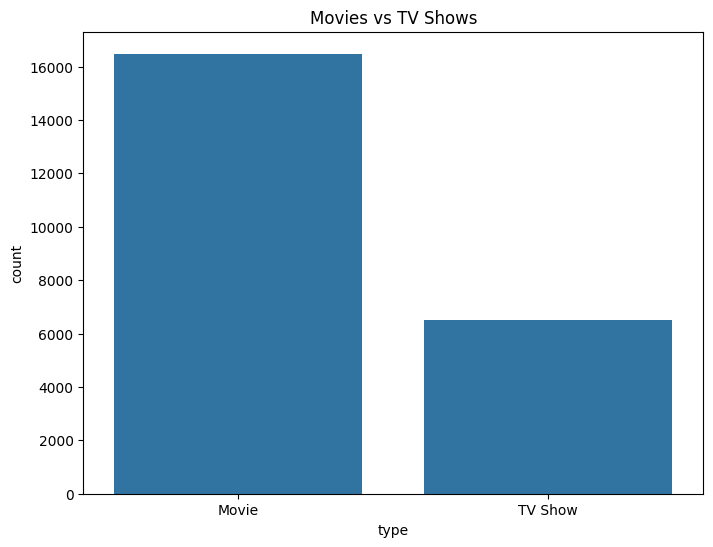

In [19]:
type_counts = df['type'].value_counts()
type_percent = df['type'].value_counts(normalize=True) * 100

print("Types:")
print(type_counts)
print(f"\nPercent:")
print(type_percent)

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='type')
plt.title('Movies vs TV Shows')
plt.show()

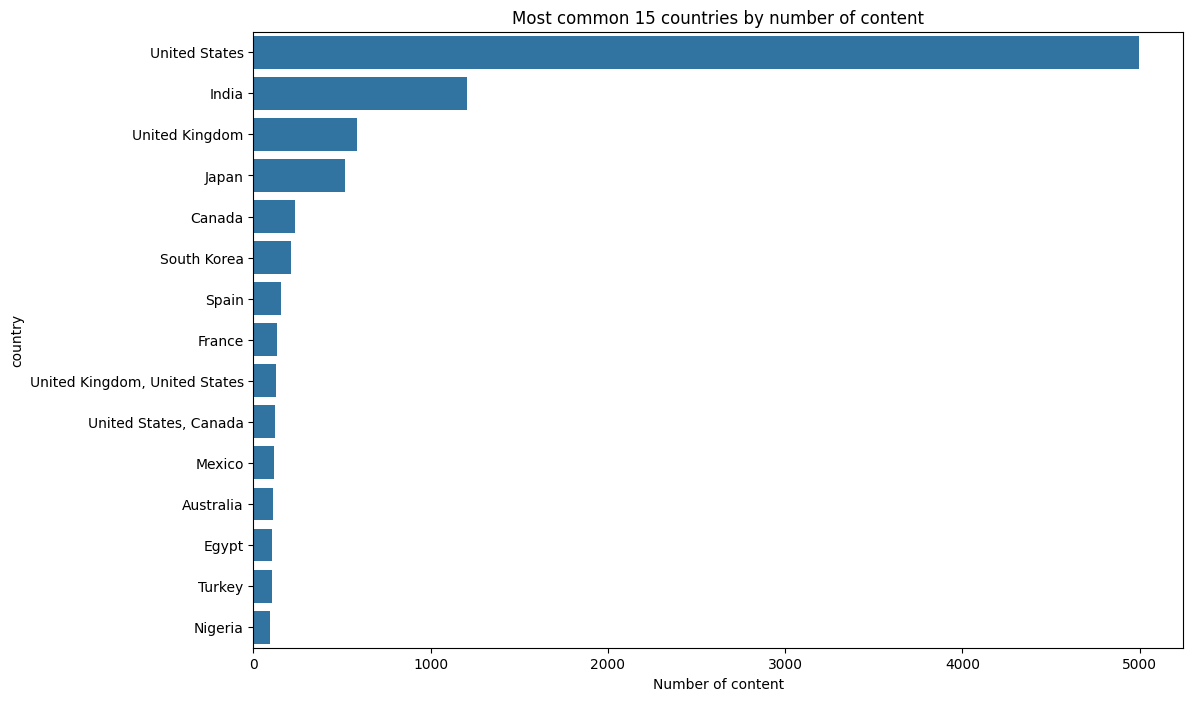

MOst common 10 countries:
country
United States                    4997
India                            1203
United Kingdom                    583
Japan                             515
Canada                            237
South Korea                       211
Spain                             156
France                            132
United Kingdom, United States     127
United States, Canada             123
Name: count, dtype: int64


In [20]:
country_counts = df['country'].value_counts().head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x=country_counts.values, y=country_counts.index)
plt.title('Most common 15 countries by number of content')
plt.xlabel('Number of content')
plt.show()

print("MOst common 10 countries:")
print(country_counts.head(10))

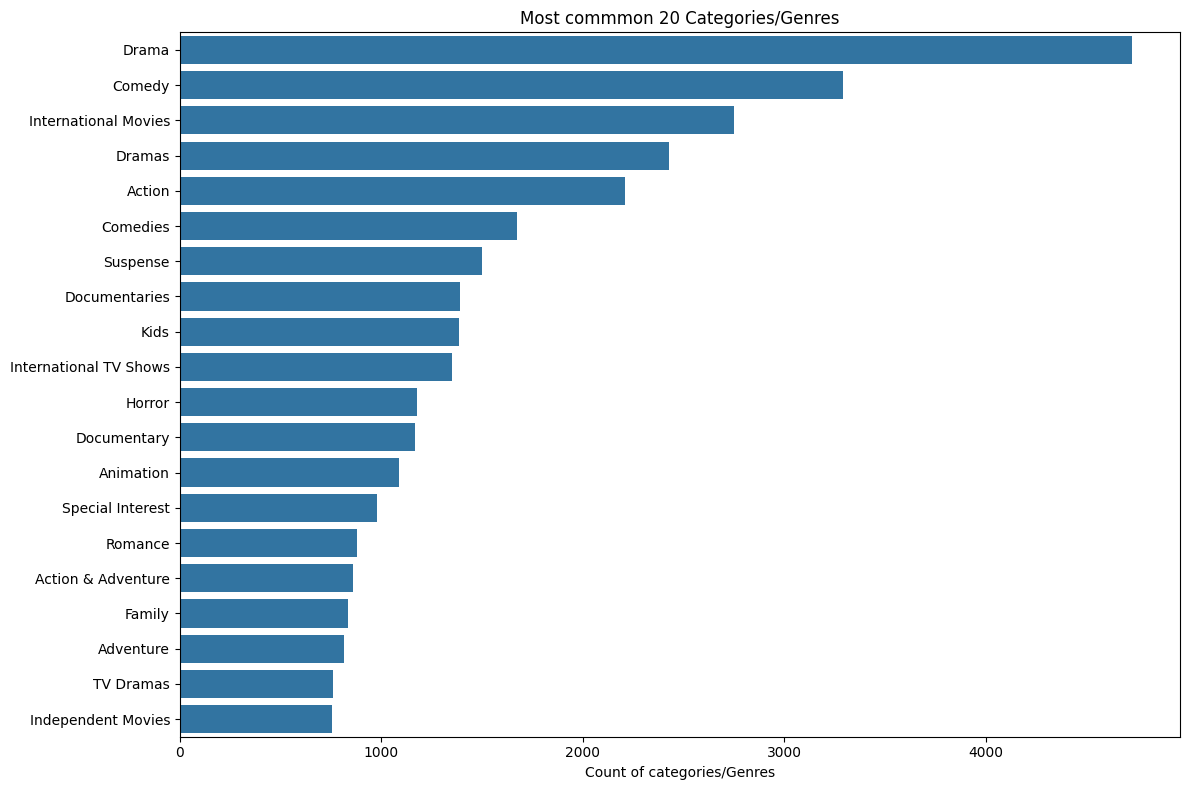

Most common 10 categories:
Drama: 4728
Comedy: 3292
International Movies: 2752
Dramas: 2427
Action: 2212
Comedies: 1674
Suspense: 1501
Documentaries: 1393
Kids: 1388
International TV Shows: 1351


In [21]:
from collections import Counter

all_categories = []
for categories in df['listed_in'].dropna():
    cats = [cat.strip() for cat in categories.split(',')]
    all_categories.extend(cats)

category_counts = Counter(all_categories).most_common(20)

plt.figure(figsize=(12, 8))
categories, counts = zip(*category_counts)
sns.barplot(x=counts, y=categories)
plt.title('Most commmon 20 Categories/Genres')
plt.xlabel('Count of categories/Genres')
plt.tight_layout()
plt.show()

print("Most common 10 categories:")
for category, count in category_counts[:10]:
    print(f"{category}: {count}")

Streaming distribution:
streaming
Prime Video    9668
Netflix        8807
Hulu           3073
Disney+        1450
Name: count, dtype: int64


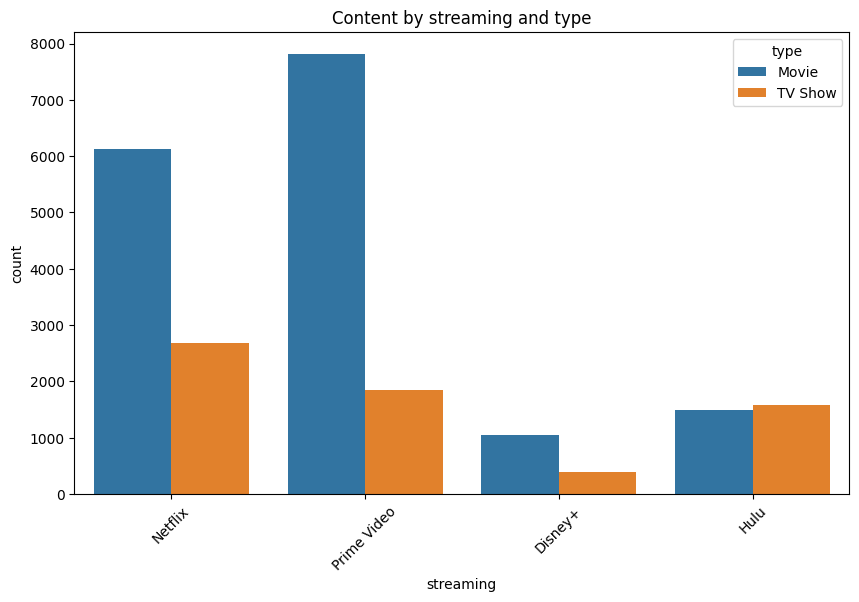

In [22]:
print("Streaming distribution:")
print(df['streaming'].value_counts())

if len(df['streaming'].unique()) > 1:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x='streaming', hue='type')
    plt.title('Content by streaming and type')
    plt.xticks(rotation=45)
    plt.show()